# Constructing X Eval

This notebook explores how the construction of the evaluation set X affects fidelity measurements.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [1]:
%pip install numpy pandas matplotlib scikit-learn torch scipy -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Hybrid Evaluation Set Generation

We construct hybrid evaluation sets by progressively mixing natural test data with pure boundary-sampled points to systematically stress-test the surrogate.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy import stats

from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [3]:
BASE_SEED = 42
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)
DEVICE = "cpu"
print("Using device:", DEVICE)


Using device: cpu


In [4]:
# -----------------------------------------------------------------------------
# Dataset generators
# -----------------------------------------------------------------------------

def make_xor(n_samples=1500, noise=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    X = rng.normal(size=(n_samples, 2))
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_checkerboard(n_samples=1500, noise=0.03, random_state=42, cells=4):
    rng = np.random.default_rng(random_state)
    X = rng.uniform(-2, 2, size=(n_samples, 2))
    cell_x = np.floor((X[:, 0] + 2) / 4 * cells).astype(int)
    cell_y = np.floor((X[:, 1] + 2) / 4 * cells).astype(int)
    y = ((cell_x + cell_y) % 2).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_warped_blobs(n_samples=1500, noise=0.08, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.2, -0.2), (1.2, 0.2)],
        cluster_std=[0.65, 0.65],
        random_state=random_state,
    )
    X = X.copy()
    X[:, 1] = X[:, 1] + 0.85 * np.sin(1.4 * X[:, 0])
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_linear_blobs(n_samples=1500, noise=0.05, random_state=42):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=[(-1.4, 0), (1.4, 0)],
        cluster_std=[0.55, 0.55],
        random_state=random_state,
    )
    rng = np.random.default_rng(random_state)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def make_gaussian_overlap(n_samples=1500, random_state=42):
    rng = np.random.default_rng(random_state)
    n0 = n_samples // 2
    n1 = n_samples - n0

    mean0 = np.array([-0.65, 0.0])
    mean1 = np.array([0.65, 0.0])
    cov0 = np.array([[1.0, 0.55], [0.55, 0.85]])
    cov1 = np.array([[1.0, -0.45], [-0.45, 0.85]])

    X0 = rng.multivariate_normal(mean0, cov0, size=n0)
    X1 = rng.multivariate_normal(mean1, cov1, size=n1)
    X = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])

    perm = rng.permutation(n_samples)
    return X[perm], y[perm]


def load_dataset(name, n_samples=1500, random_state=42):
    if name == "moons":
        return make_moons(n_samples=n_samples, noise=0.25, random_state=random_state)
    if name == "circles":
        return make_circles(n_samples=n_samples, noise=0.25, factor=0.45, random_state=random_state)
    if name == "xor":
        return make_xor(n_samples=n_samples, random_state=random_state)
    if name == "checkerboard":
        return make_checkerboard(n_samples=n_samples, random_state=random_state)
    if name == "warped_blobs":
        return make_warped_blobs(n_samples=n_samples, random_state=random_state)
    if name == "linear_blobs":
        return make_linear_blobs(n_samples=n_samples, random_state=random_state)
    if name == "gaussian_overlap":
        return make_gaussian_overlap(n_samples=n_samples, random_state=random_state)
    raise ValueError(f"Unknown dataset: {name}")


### Model Training

Here we initialize and train the teacher models, followed by the respective surrogate approximation models.

In [5]:
# -----------------------------------------------------------------------------
# Teacher model
# -----------------------------------------------------------------------------

class TeacherMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_teacher(X_train, y_train, seed=42, epochs=500, batch_size=64, lr=1e-3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = TeacherMLP(input_dim=X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    return model


def teacher_probs(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        return torch.sigmoid(logits).cpu().numpy()


In [6]:
# -----------------------------------------------------------------------------
# Surrogate models
# -----------------------------------------------------------------------------

def fit_surrogate(name, X_train, teacher_train_y, seed=42):
    if name == "logistic_regression":
        model = LogisticRegression(max_iter=1000, random_state=seed)
    elif name == "linear_svm_calibrated":
        base = LinearSVC(max_iter=5000, random_state=seed)
        model = CalibratedClassifierCV(base, method="sigmoid", cv=3)
    elif name == "decision_tree_depth_2":
        model = DecisionTreeClassifier(max_depth=2, random_state=seed)
    elif name == "decision_tree_depth_4":
        model = DecisionTreeClassifier(max_depth=4, random_state=seed)
    elif name == "small_mlp_surrogate":
        model = MLPClassifier(
            hidden_layer_sizes=(8,),
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=seed,
        )
    else:
        raise ValueError(f"Unknown surrogate: {name}")

    model.fit(X_train, teacher_train_y)
    return model


def surrogate_probs(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


### Metric Sensitivity to Evaluation Sets

We compute confidence-weighted and geometry-weighted fidelities across these hybrid sets to show how sensitive the standard fidelity metric is to the choice of $X_{eval}$.

In [7]:
# -----------------------------------------------------------------------------
# Fidelity and weighting functions
# -----------------------------------------------------------------------------

def hard_agreement(teacher_p, surrogate_p):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)
    return (teacher_y == surrogate_y).astype(float)


def teacher_margin(teacher_p):
    return np.abs(teacher_p - 0.5)


def normalized_weighted_average(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)

    if valid.sum() == 0 or weights[valid].sum() == 0:
        return np.nan

    return float(np.sum(values[valid] * weights[valid]) / np.sum(weights[valid]))


def confidence_weights(teacher_p, alpha=10.0):
    return np.exp(-alpha * teacher_margin(teacher_p))


def geometry_weights(boundary_distances, beta=2.0):
    return np.exp(-beta * boundary_distances)


In [8]:
# -----------------------------------------------------------------------------
# Boundary approximation and boundary sampling
# -----------------------------------------------------------------------------

def make_grid(X, margin=0.75, grid_size=350):
    x_min = X[:, 0].min() - margin
    x_max = X[:, 0].max() + margin
    y_min = X[:, 1].min() - margin
    y_max = X[:, 1].max() + margin

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def approximate_boundary_points(teacher, X_reference, grid_size=350, margin=0.75, band_eps=0.015, fallback_k=2500):
    xx, yy, grid = make_grid(X_reference, margin=margin, grid_size=grid_size)
    grid_p = teacher_probs(teacher, grid)
    margins = np.abs(grid_p - 0.5)

    boundary_points = grid[margins <= band_eps]
    used_fallback = False

    if len(boundary_points) < 50:
        used_fallback = True
        k = min(fallback_k, len(grid))
        closest_idx = np.argpartition(margins, k - 1)[:k]
        boundary_points = grid[closest_idx]

    return {
        "xx": xx,
        "yy": yy,
        "grid": grid,
        "grid_p": grid_p,
        "grid_margins": margins,
        "boundary_points": boundary_points,
        "used_fallback": used_fallback,
    }


def nearest_boundary_distances(X_eval, boundary_points):
    tree = cKDTree(boundary_points)
    distances, _ = tree.query(X_eval, k=1)
    return distances


def sample_boundary_points(boundary_points, n_points, seed=42):
    rng = np.random.default_rng(seed)
    if len(boundary_points) == 0:
        raise ValueError("No boundary points available for sampling.")
    idx = rng.choice(len(boundary_points), size=n_points, replace=len(boundary_points) < n_points)
    return boundary_points[idx]


In [9]:
# -----------------------------------------------------------------------------
# Evaluation-set construction
# -----------------------------------------------------------------------------

def construct_eval_sets(X_test, boundary_points, seed=42, boundary_ratios=(0.10, 0.25, 0.50, 1.00)):
    """
    Construct several X_eval choices.

    1. natural_test:
       X_eval = X_test

    2. boundary_only:
       X_eval = sampled boundary points, same size as X_test

    3. hybrid_equal:
       X_eval = X_test union boundary sample of equal size

    4. hybrid_boundary_ratio_r:
       X_eval = X_test union boundary sample of size r * len(X_test)
    """
    eval_sets = {}
    n_test = len(X_test)

    eval_sets["natural_test"] = X_test
    eval_sets["boundary_only"] = sample_boundary_points(boundary_points, n_test, seed=seed + 1000)
    eval_sets["hybrid_equal"] = np.vstack([
        X_test,
        sample_boundary_points(boundary_points, n_test, seed=seed + 2000),
    ])

    for ratio in boundary_ratios:
        n_boundary = max(1, int(round(ratio * n_test)))
        eval_sets[f"hybrid_boundary_ratio_{ratio:.2f}"] = np.vstack([
            X_test,
            sample_boundary_points(boundary_points, n_boundary, seed=seed + int(10000 * ratio)),
        ])

    return eval_sets


In [10]:
# -----------------------------------------------------------------------------
# Single experimental run
# -----------------------------------------------------------------------------

def evaluate_on_X_eval(X_eval, teacher, surrogate, boundary_points, alpha=10.0, beta=2.0):
    teacher_p = teacher_probs(teacher, X_eval)
    surrogate_p = surrogate_probs(surrogate, X_eval)
    agreement = hard_agreement(teacher_p, surrogate_p)

    distances = nearest_boundary_distances(X_eval, boundary_points)
    conf_w = confidence_weights(teacher_p, alpha=alpha)
    geo_w = geometry_weights(distances, beta=beta)

    boundary_mask = teacher_margin(teacher_p) <= 0.10

    return {
        "n_eval": len(X_eval),
        "boundary_fraction_in_eval": float(boundary_mask.mean()),
        "global_fidelity": float(np.mean(agreement)),
        "boundary_band_fidelity": float(np.mean(agreement[boundary_mask])) if boundary_mask.sum() > 0 else np.nan,
        "confidence_weighted_fidelity": normalized_weighted_average(agreement, conf_w),
        "geometry_weighted_fidelity": normalized_weighted_average(agreement, geo_w),
        "global_minus_confidence": float(np.mean(agreement)) - normalized_weighted_average(agreement, conf_w),
        "global_minus_geometry": float(np.mean(agreement)) - normalized_weighted_average(agreement, geo_w),
        "confidence_minus_geometry": normalized_weighted_average(agreement, conf_w) - normalized_weighted_average(agreement, geo_w),
        "margin_distance_spearman": stats.spearmanr(teacher_margin(teacher_p), distances).correlation,
    }


def run_one_case(dataset_name, seed, surrogate_name, alpha=10.0, beta=2.0):
    X, y = load_dataset(dataset_name, random_state=seed)
    X = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.35,
        random_state=seed,
        stratify=y,
    )

    teacher = train_teacher(X_train, y_train, seed=seed)
    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)

    surrogate = fit_surrogate(surrogate_name, X_train, teacher_train_y, seed=seed)

    boundary_info = approximate_boundary_points(teacher, X_reference=X)
    eval_sets = construct_eval_sets(
        X_test,
        boundary_info["boundary_points"],
        seed=seed,
    )

    rows = []
    for eval_set_name, X_eval in eval_sets.items():
        metrics = evaluate_on_X_eval(
            X_eval,
            teacher,
            surrogate,
            boundary_info["boundary_points"],
            alpha=alpha,
            beta=beta,
        )
        metrics.update({
            "dataset": dataset_name,
            "seed": seed,
            "surrogate": surrogate_name,
            "eval_set": eval_set_name,
            "n_boundary_grid_points": len(boundary_info["boundary_points"]),
            "used_boundary_fallback": boundary_info["used_fallback"],
        })
        rows.append(metrics)

    return rows


In [11]:
# -----------------------------------------------------------------------------
# Run X_eval construction experiment
# -----------------------------------------------------------------------------

datasets = [
    "moons",
    "warped_blobs",
    "gaussian_overlap",
    "linear_blobs",
    "xor",
    "checkerboard",
    "circles",
]

surrogates = [
    "logistic_regression",
    "linear_svm_calibrated",
    "decision_tree_depth_2",
    "decision_tree_depth_4",
    "small_mlp_surrogate",
]

seeds = list(range(5))

rows = []

for dataset_name in datasets:
    print(f"\n=== Dataset: {dataset_name} ===")
    for seed in seeds:
        print(f"  seed {seed}")
        for surrogate_name in surrogates:
            rows.extend(run_one_case(dataset_name, seed, surrogate_name))

results = pd.DataFrame(rows)
results



=== Dataset: moons ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: warped_blobs ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: gaussian_overlap ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: linear_blobs ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: xor ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: checkerboard ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4

=== Dataset: circles ===
  seed 0
  seed 1
  seed 2
  seed 3
  seed 4


,n_eval,boundary_fraction_in_eval,global_fidelity,boundary_band_fidelity,confidence_weighted_fidelity,geometry_weighted_fidelity,global_minus_confidence,global_minus_geometry,confidence_minus_geometry,margin_distance_spearman,dataset,seed,surrogate,eval_set,n_boundary_grid_points,used_boundary_fallback
0,525,0.019048,0.883810,0.800000,0.724128,0.792097,0.159682,0.091712,-0.067970,0.798174,moons,0,logistic_regression,natural_test,255,False
1,525,1.000000,0.641905,0.641905,0.642364,0.641905,-0.000459,0.000000,0.000459,NaN,moons,0,logistic_regression,boundary_only,255,False
2,1050,0.509524,0.740952,0.601869,0.603426,0.651075,0.137526,0.089877,-0.047649,0.905042,moons,0,logistic_regression,hybrid_equal,255,False
3,577,0.107452,0.863085,0.677419,0.673203,0.763253,0.189882,0.099832,-0.090050,0.847372,moons,0,logistic_regression,hybrid_boundary_ratio_0.10,255,False
4,656,0.214939,0.827744,0.617021,0.619765,0.716649,0.207979,0.111095,-0.096884,0.891305,moons,0,logistic_regression,hybrid_boundary_ratio_0.25,255,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220,1050,0.530476,0.744762,0.520646,0.533063,0.654901,0.211699,0.089861,-0.121838,0.919228,circles,4,small_mlp_surrogate,hybrid_equal,373,False
1221,577,0.145581,0.932409,0.547619,0.620692,0.872901,0.311717,0.059508,-0.252209,0.947328,circles,4,small_mlp_surrogate,hybrid_boundary_ratio_0.10,373,False
1222,656,0.248476,0.890244,0.564417,0.602066,0.812591,0.288178,0.077653,-0.210525,0.958905,circles,4,small_mlp_surrogate,hybrid_boundary_ratio_0.25,373,False
1223,787,0.373571,0.824651,0.534014,0.556973,0.731586,0.267678,0.093065,-0.174613,0.956631,circles,4,small_mlp_surrogate,hybrid_boundary_ratio_0.50,373,False


### Artifact Export

Saving the tabular results and figures for downstream inclusion in the paper.

In [12]:
results.to_csv("constructing_X_eval_results.csv", index=False)
print("Saved constructing_X_eval_results.csv")


Saved constructing_X_eval_results.csv


In [13]:
# -----------------------------------------------------------------------------
# Aggregate summaries
# -----------------------------------------------------------------------------

summary = (
    results
    .groupby(["dataset", "eval_set"])
    .agg(
        n_eval_mean=("n_eval", "mean"),
        boundary_fraction_mean=("boundary_fraction_in_eval", "mean"),
        global_fidelity_mean=("global_fidelity", "mean"),
        boundary_band_fidelity_mean=("boundary_band_fidelity", "mean"),
        confidence_weighted_mean=("confidence_weighted_fidelity", "mean"),
        geometry_weighted_mean=("geometry_weighted_fidelity", "mean"),
        global_minus_confidence_mean=("global_minus_confidence", "mean"),
        global_minus_geometry_mean=("global_minus_geometry", "mean"),
        confidence_minus_geometry_mean=("confidence_minus_geometry", "mean"),
        margin_distance_spearman_mean=("margin_distance_spearman", "mean"),
    )
    .reset_index()
)

summary


,dataset,eval_set,n_eval_mean,boundary_fraction_mean,global_fidelity_mean,boundary_band_fidelity_mean,confidence_weighted_mean,geometry_weighted_mean,global_minus_confidence_mean,global_minus_geometry_mean,confidence_minus_geometry_mean,margin_distance_spearman_mean
0,checkerboard,boundary_only,525.0,1.000000,0.501410,0.501410,0.502153,0.501410,-0.000744,0.000000,0.000744,NaN
1,checkerboard,hybrid_boundary_ratio_0.10,577.0,0.116811,0.557227,0.463569,0.478538,0.545895,0.078689,0.011332,-0.067357,0.936474
2,checkerboard,hybrid_boundary_ratio_0.25,656.0,0.223171,0.552195,0.492509,0.498873,0.540909,0.053322,0.011286,-0.042036,0.952291
3,checkerboard,hybrid_boundary_ratio_0.50,787.0,0.352478,0.544854,0.500034,0.502980,0.533915,0.041874,0.010939,-0.030935,0.954827
4,checkerboard,hybrid_boundary_ratio_1.00,1050.0,0.514667,0.537029,0.506595,0.508524,0.527814,0.028504,0.009214,-0.019290,0.922284
5,checkerboard,hybrid_equal,1050.0,0.514667,0.535200,0.503063,0.504597,0.525614,0.030603,0.009586,-0.021018,0.922264
6,checkerboard,natural_test,525.0,0.029333,0.566019,0.438908,0.504638,0.557301,0.061381,0.008718,-0.052662,0.916549
7,circles,boundary_only,525.0,1.000000,0.517105,0.517105,0.516015,0.517105,0.001090,0.000000,-0.001090,NaN
8,circles,hybrid_boundary_ratio_0.10,577.0,0.155633,0.724922,0.534295,0.561776,0.678822,0.163146,0.046100,-0.117046,0.953954
9,circles,hybrid_boundary_ratio_0.25,656.0,0.257317,0.700854,0.530560,0.545668,0.646430,0.155186,0.054424,-0.100762,0.963416


In [14]:
summary.to_csv("constructing_X_eval_summary.csv", index=False)
print("Saved constructing_X_eval_summary.csv")


Saved constructing_X_eval_summary.csv


### Visualization

Finally, we visualize the spatial structure of teacher-surrogate disagreement to demonstrate the impact of locality weighting.

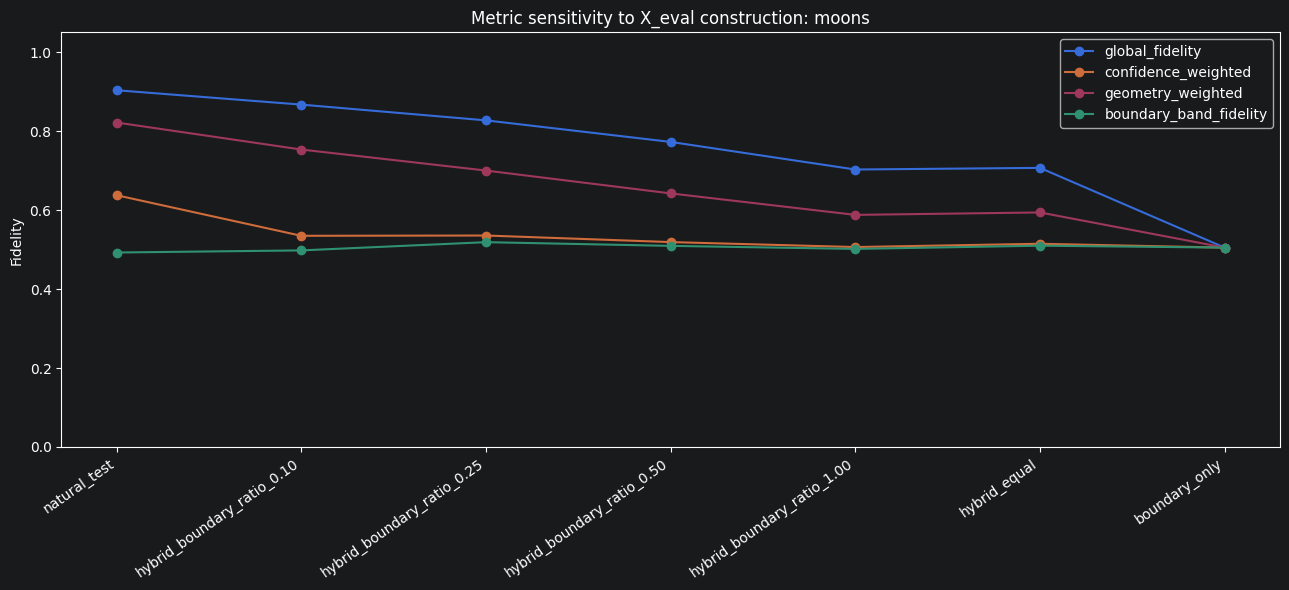

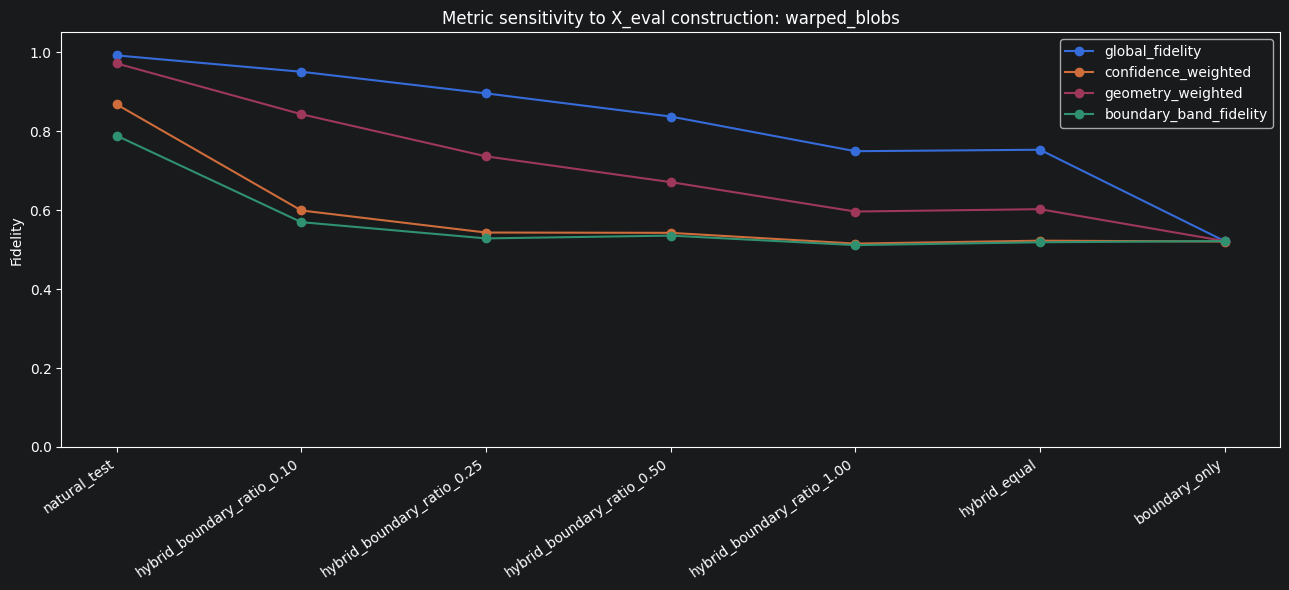

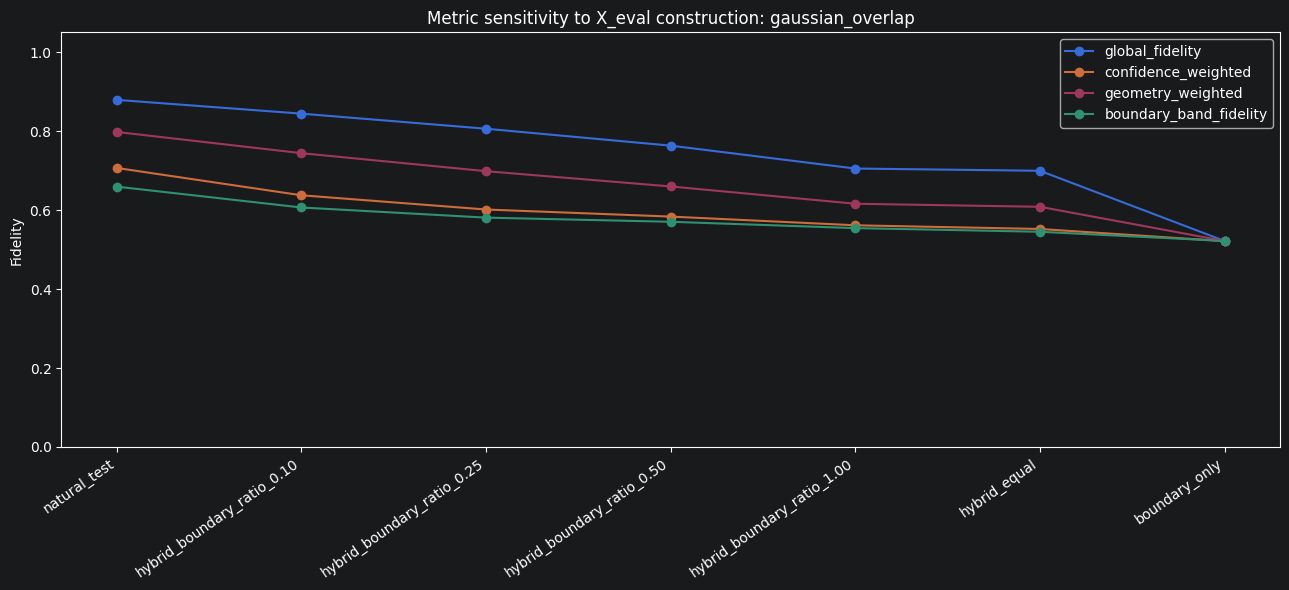

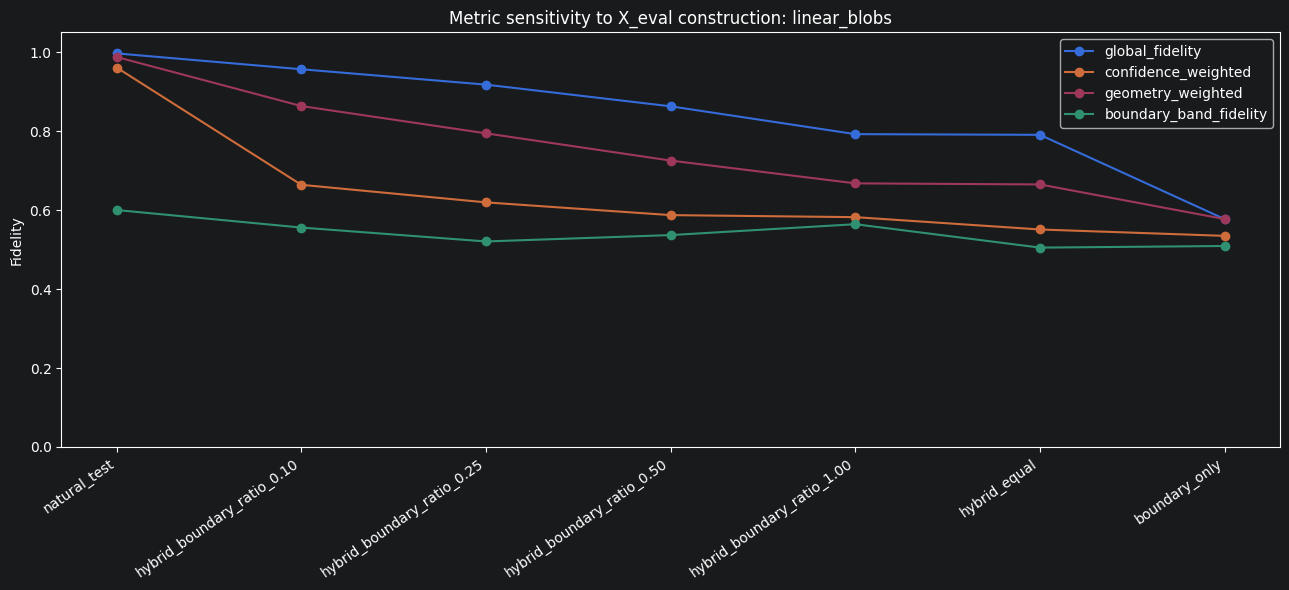

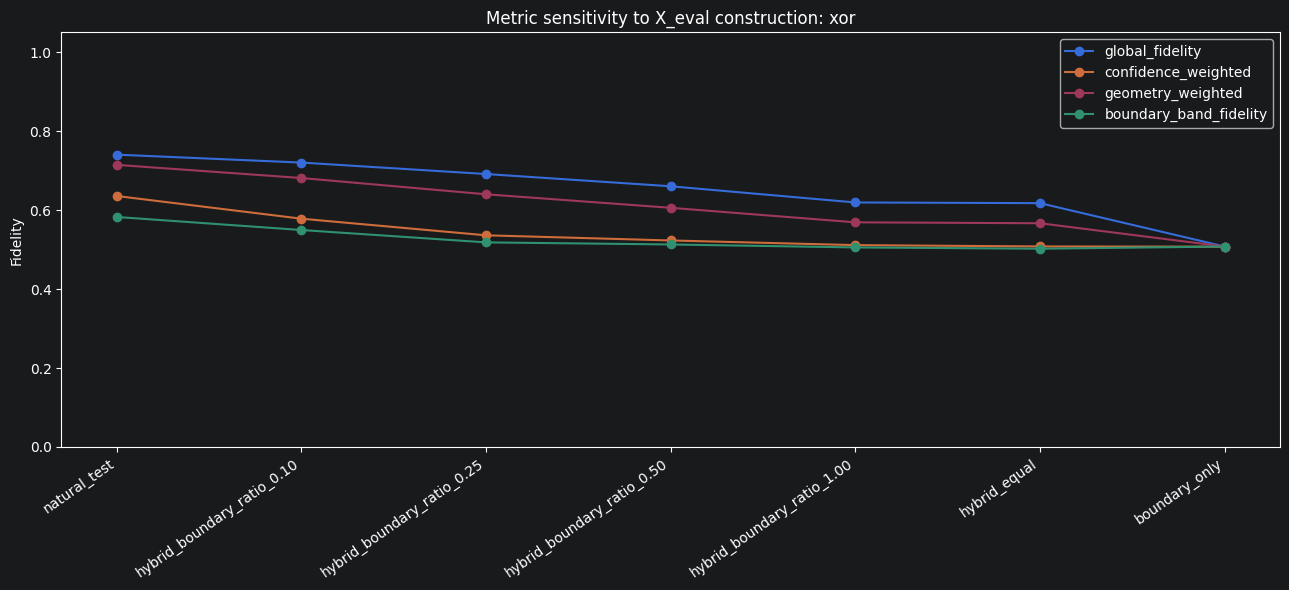

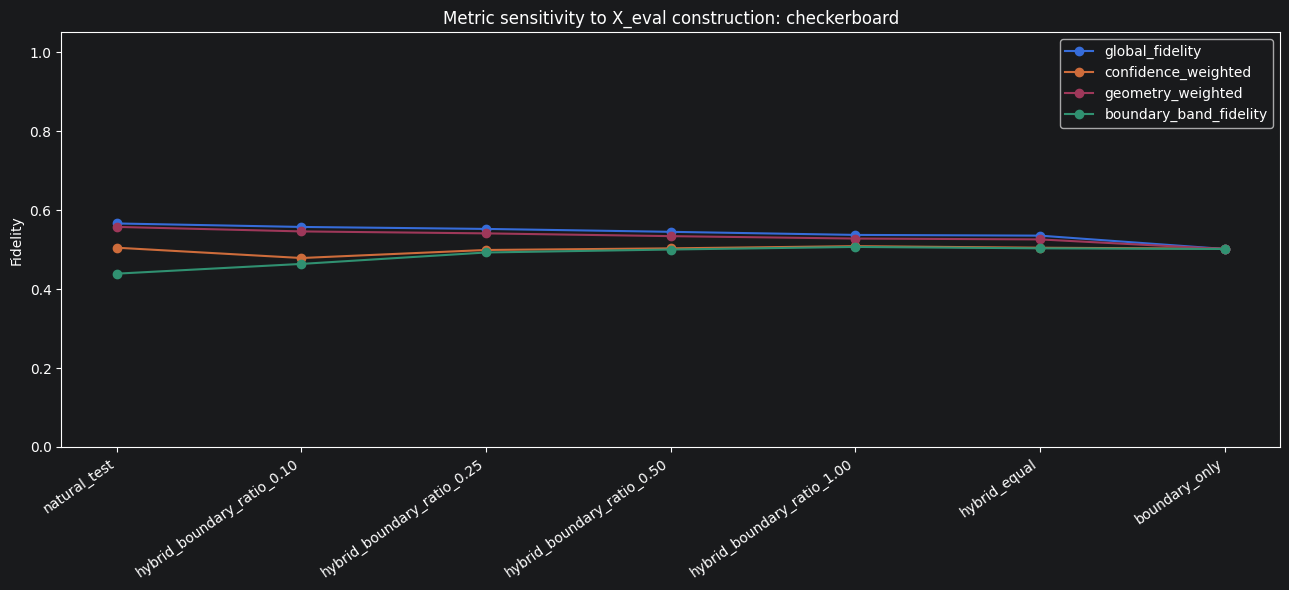

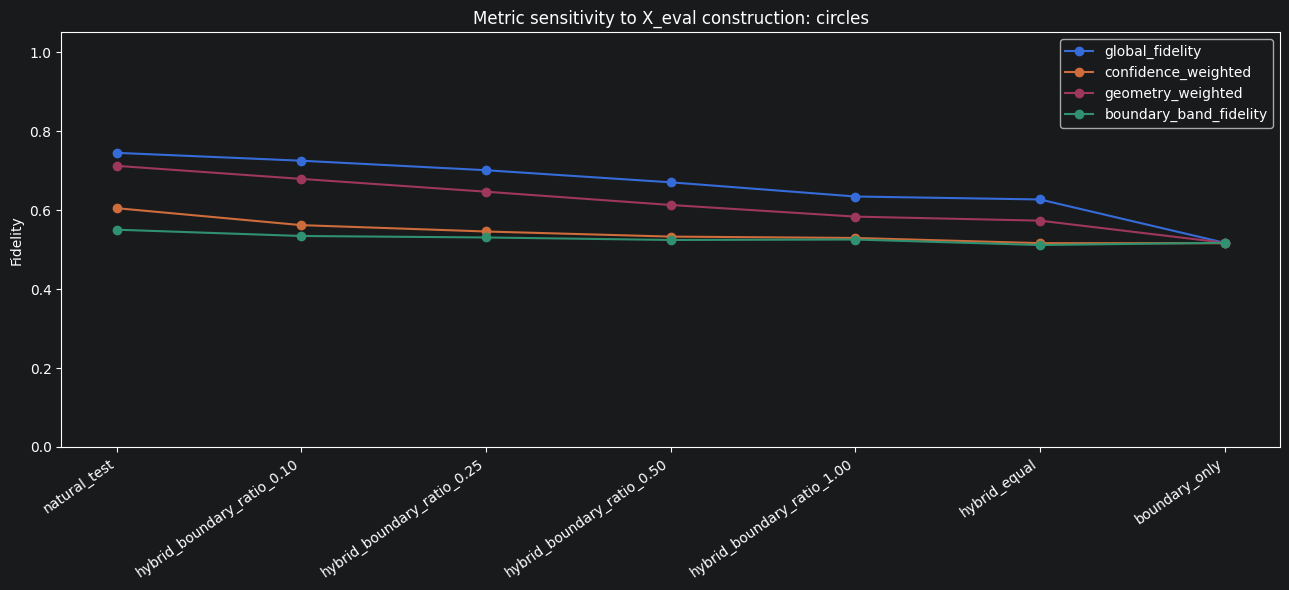

In [15]:
# -----------------------------------------------------------------------------
# Plot: metric sensitivity to X_eval construction
# -----------------------------------------------------------------------------

metric_cols = [
    "global_fidelity_mean",
    "confidence_weighted_mean",
    "geometry_weighted_mean",
    "boundary_band_fidelity_mean",
]

eval_order = [
    "natural_test",
    "hybrid_boundary_ratio_0.10",
    "hybrid_boundary_ratio_0.25",
    "hybrid_boundary_ratio_0.50",
    "hybrid_boundary_ratio_1.00",
    "hybrid_equal",
    "boundary_only",
]

for dataset_name in datasets:
    subset = summary[summary["dataset"] == dataset_name].copy()
    subset["eval_set"] = pd.Categorical(subset["eval_set"], categories=eval_order, ordered=True)
    subset = subset.sort_values("eval_set")

    fig, ax = plt.subplots(figsize=(13, 6))
    x = np.arange(len(subset))

    for metric in metric_cols:
        ax.plot(
            x,
            subset[metric],
            marker="o",
            label=metric.replace("_mean", ""),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(subset["eval_set"], rotation=35, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Fidelity")
    ax.set_title(f"Metric sensitivity to X_eval construction: {dataset_name}")
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"X_eval_metric_sensitivity_{dataset_name}.png", dpi=200)
    plt.show()


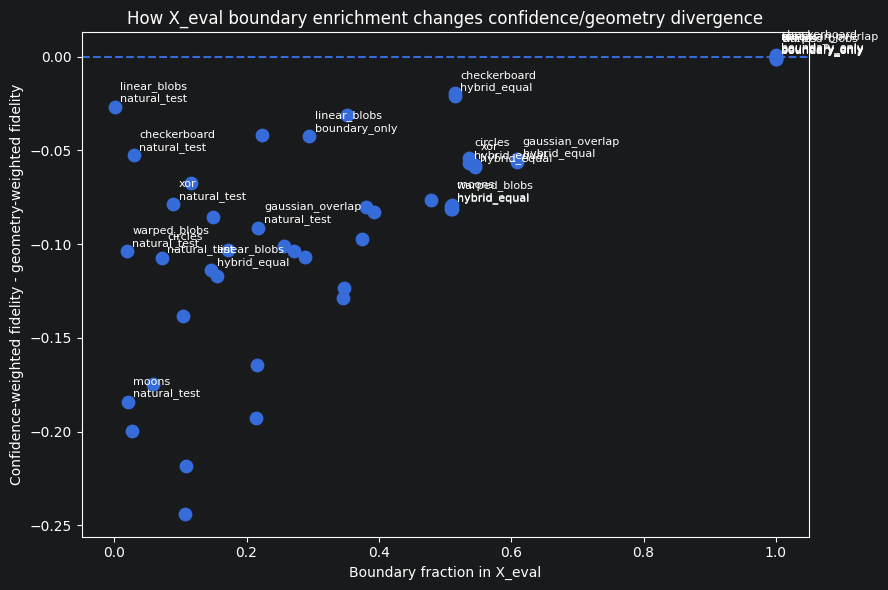

In [16]:
# -----------------------------------------------------------------------------
# Plot: boundary fraction vs weighted divergence
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    summary["boundary_fraction_mean"],
    summary["confidence_minus_geometry_mean"],
    s=80,
)

for _, row in summary.iterrows():
    if row["eval_set"] in ["natural_test", "hybrid_equal", "boundary_only"]:
        ax.annotate(
            f"{row['dataset']}\n{row['eval_set']}",
            (row["boundary_fraction_mean"], row["confidence_minus_geometry_mean"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )

ax.axhline(0, linestyle="--")
ax.set_xlabel("Boundary fraction in X_eval")
ax.set_ylabel("Confidence-weighted fidelity - geometry-weighted fidelity")
ax.set_title("How X_eval boundary enrichment changes confidence/geometry divergence")

plt.tight_layout()
plt.savefig("X_eval_boundary_fraction_vs_conf_geo_difference.png", dpi=200)
plt.show()


In [17]:
# -----------------------------------------------------------------------------
# Ranking stability under X_eval construction
# -----------------------------------------------------------------------------

ranking_rows = []

for (dataset_name, eval_set_name), group in results.groupby(["dataset", "eval_set"]):
    surrogate_summary = (
        group
        .groupby("surrogate")
        .agg(
            global_fidelity=("global_fidelity", "mean"),
            confidence_weighted_fidelity=("confidence_weighted_fidelity", "mean"),
            geometry_weighted_fidelity=("geometry_weighted_fidelity", "mean"),
        )
        .reset_index()
    )

    for metric in ["global_fidelity", "confidence_weighted_fidelity", "geometry_weighted_fidelity"]:
        ranked = surrogate_summary.sort_values(metric, ascending=False).reset_index(drop=True)
        for rank, row in ranked.iterrows():
            ranking_rows.append({
                "dataset": dataset_name,
                "eval_set": eval_set_name,
                "metric": metric,
                "rank": rank + 1,
                "surrogate": row["surrogate"],
                "score": row[metric],
            })

rankings = pd.DataFrame(ranking_rows)
rankings


,dataset,eval_set,metric,rank,surrogate,score
0,checkerboard,boundary_only,global_fidelity,1,decision_tree_depth_2,0.516952
1,checkerboard,boundary_only,global_fidelity,2,small_mlp_surrogate,0.511238
2,checkerboard,boundary_only,global_fidelity,3,linear_svm_calibrated,0.507429
3,checkerboard,boundary_only,global_fidelity,4,logistic_regression,0.491810
4,checkerboard,boundary_only,global_fidelity,5,decision_tree_depth_4,0.479619
...,...,...,...,...,...,...
730,xor,natural_test,geometry_weighted_fidelity,1,small_mlp_surrogate,0.916295
731,xor,natural_test,geometry_weighted_fidelity,2,decision_tree_depth_4,0.905598
732,xor,natural_test,geometry_weighted_fidelity,3,decision_tree_depth_2,0.667567
733,xor,natural_test,geometry_weighted_fidelity,4,logistic_regression,0.548817


In [18]:
rankings.to_csv("constructing_X_eval_rankings.csv", index=False)
print("Saved constructing_X_eval_rankings.csv")


Saved constructing_X_eval_rankings.csv


In [19]:
top_surrogates = (
    rankings[rankings["rank"] == 1]
    .pivot_table(
        index=["dataset", "eval_set"],
        columns="metric",
        values="surrogate",
        aggfunc="first",
    )
    .reset_index()
)

top_surrogates


metric,dataset,eval_set,confidence_weighted_fidelity,geometry_weighted_fidelity,global_fidelity
0,checkerboard,boundary_only,decision_tree_depth_2,decision_tree_depth_2,decision_tree_depth_2
1,checkerboard,hybrid_boundary_ratio_0.10,small_mlp_surrogate,decision_tree_depth_4,decision_tree_depth_4
2,checkerboard,hybrid_boundary_ratio_0.25,decision_tree_depth_2,decision_tree_depth_4,decision_tree_depth_4
3,checkerboard,hybrid_boundary_ratio_0.50,decision_tree_depth_2,decision_tree_depth_4,decision_tree_depth_4
4,checkerboard,hybrid_boundary_ratio_1.00,small_mlp_surrogate,decision_tree_depth_4,decision_tree_depth_4
5,checkerboard,hybrid_equal,decision_tree_depth_2,decision_tree_depth_4,decision_tree_depth_4
6,checkerboard,natural_test,decision_tree_depth_4,decision_tree_depth_4,decision_tree_depth_4
7,circles,boundary_only,small_mlp_surrogate,small_mlp_surrogate,small_mlp_surrogate
8,circles,hybrid_boundary_ratio_0.10,small_mlp_surrogate,small_mlp_surrogate,small_mlp_surrogate
9,circles,hybrid_boundary_ratio_0.25,small_mlp_surrogate,small_mlp_surrogate,small_mlp_surrogate


In [20]:
top_surrogates.to_csv("constructing_X_eval_top_surrogates.csv", index=False)
print("Saved constructing_X_eval_top_surrogates.csv")


Saved constructing_X_eval_top_surrogates.csv


In [21]:
print("Questions addressed by this notebook:")
print("1. Does the weighted-fidelity story depend on how X_eval is constructed?")
print("2. Does boundary enrichment make global fidelity look more like weighted fidelity?")
print("3. Are confidence and geometry weighting stable across natural, boundary-only, and hybrid eval sets?")
print("4. Does X_eval construction change surrogate rankings?")
print("5. Which X_eval construction is most defensible for the paper?")

Questions addressed by this notebook:
1. Does the weighted-fidelity story depend on how X_eval is constructed?
2. Does boundary enrichment make global fidelity look more like weighted fidelity?
3. Are confidence and geometry weighting stable across natural, boundary-only, and hybrid eval sets?
4. Does X_eval construction change surrogate rankings?
5. Which X_eval construction is most defensible for the paper?
